In [300]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [301]:
data_dir = Path("data")
INDIR = Path("data/data_model")
OUTDIR = Path("data/data_processed")

OUTDIR.mkdir(parents=True, exist_ok=True)

In [302]:
arquivo = INDIR / "ANALISE_NOTAS_ENEM_MUNICIPIOS_SP_CLUSTERS.csv"
df = pd.read_csv(arquivo, sep=',')


In [303]:
df.head()

,NO_MUNICIPIO_PROVA,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA,RENDA_FAMILIAR_SM_MEDIA,REGIAO,CLUSTER
0,ADAMANTINA,525.810123,554.820000,557.684444,583.616296,695.506173,2.752041,INTERIOR,1
1,AGUDOS,520.218269,540.266346,551.470513,568.333333,689.871795,2.883191,INTERIOR,1
2,AMERICANA,533.845202,558.039175,560.798216,590.087470,704.480571,3.621081,INTERIOR,1
3,AMPARO,531.318845,552.114015,559.059280,588.289583,686.837121,2.927684,INTERIOR,1
4,ANDRADINA,502.544260,524.655960,541.908609,549.461258,665.651214,2.593284,INTERIOR,0


In [304]:
df_dict = {
    0: df[df['CLUSTER'] == 0].copy().reset_index(drop=True),
    1: df[df['CLUSTER'] == 1].copy().reset_index(drop=True)
}

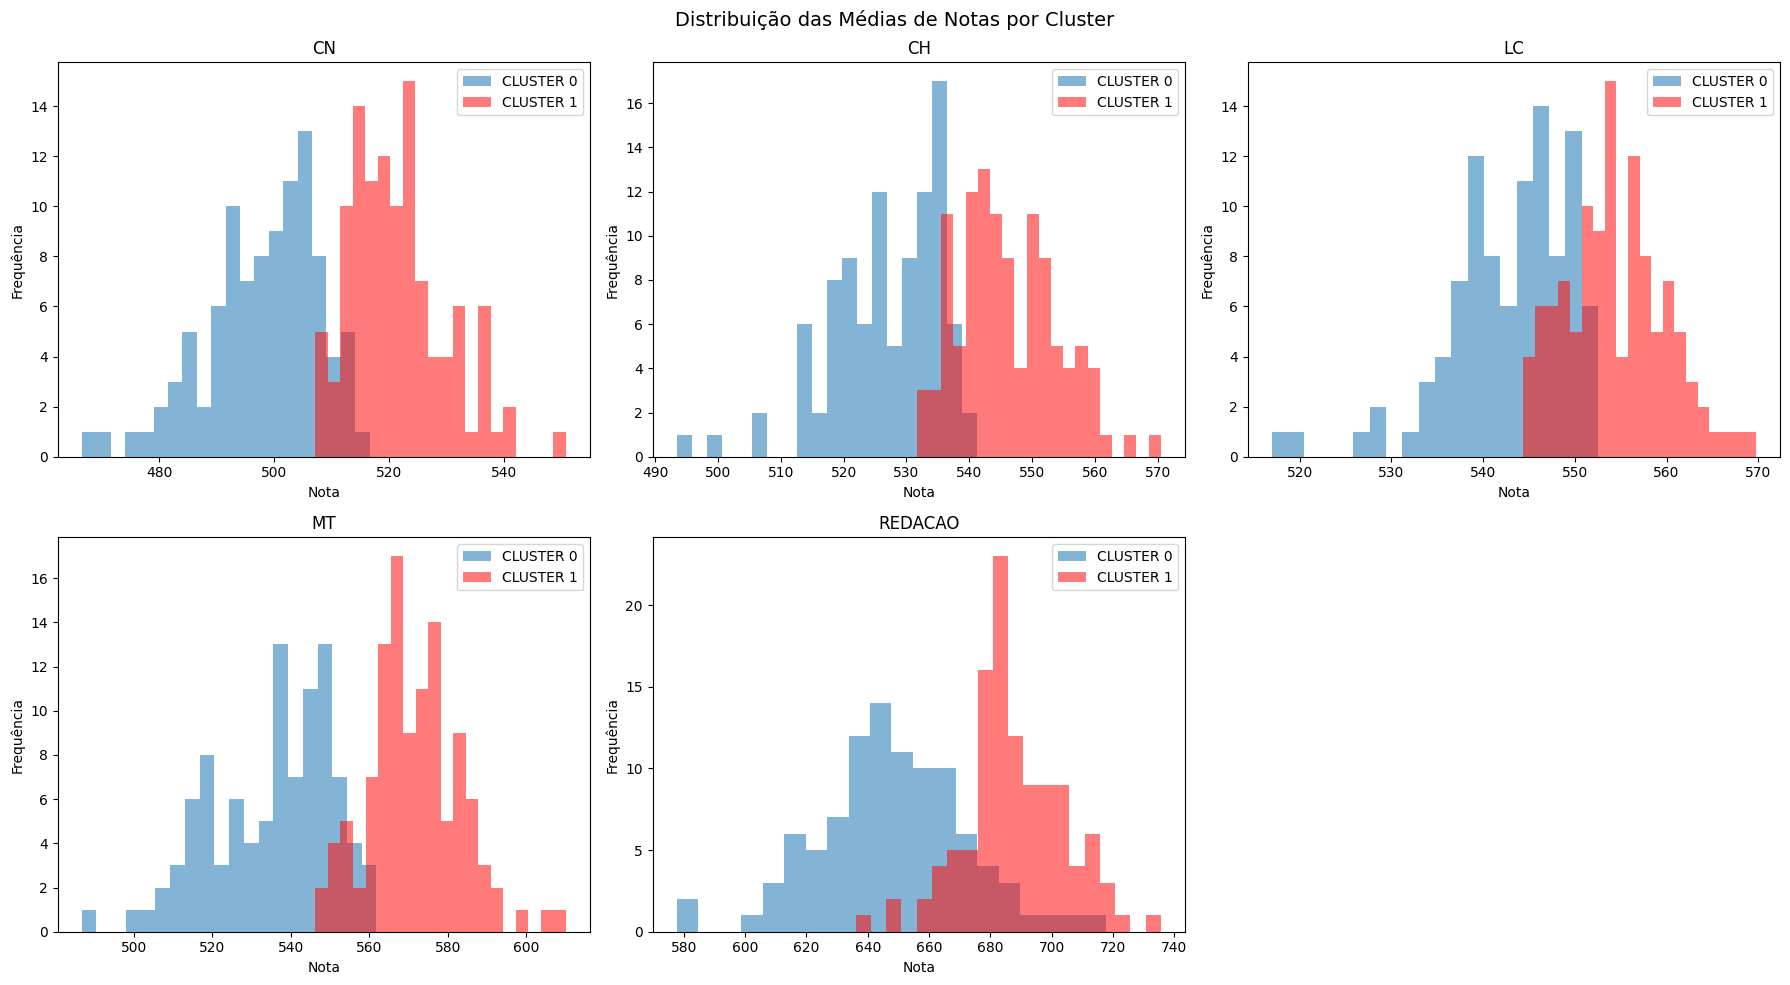

In [305]:
colunas_notas = [c for c in df.columns if c.startswith("NU_NOTA_") and c.endswith("_MEDIA")]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cores_cluster = {0: "#1f77b4", 1: "#ff0e0e"}

for i, coluna in enumerate(colunas_notas):
    ax = axes[i]
    for cluster in sorted(df["CLUSTER"].unique()):
        ax.hist(
            df.loc[df["CLUSTER"] == cluster, coluna],
            bins=20,
            alpha=0.55,
            label=f"CLUSTER {cluster}",
            color=cores_cluster.get(cluster, None)
        )
    ax.set_title(coluna.replace("NU_NOTA_", "").replace("_MEDIA", ""))
    ax.set_xlabel("Nota")
    ax.set_ylabel("Frequência")
    ax.legend()

# remove eixos não usados (caso sobrem)
for j in range(len(colunas_notas), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribuição das Médias de Notas por Cluster", fontsize=14)
plt.tight_layout()
plt.show()


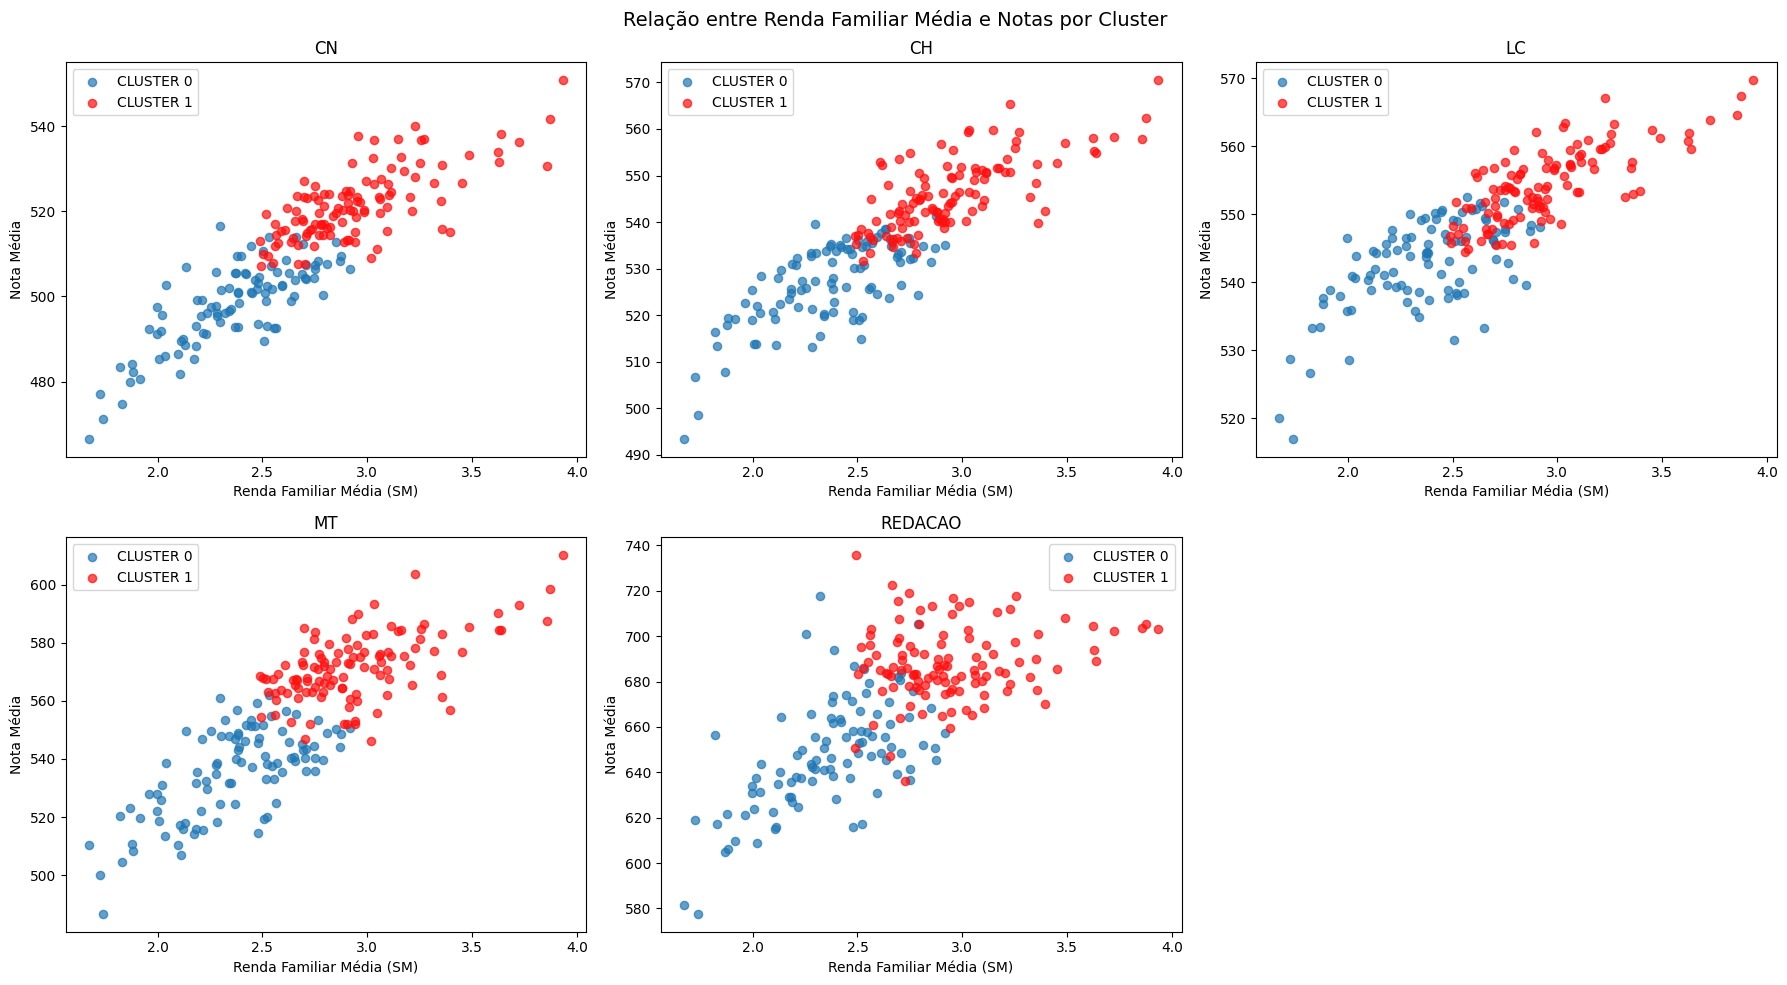

In [307]:
renda_col = "RENDA_FAMILIAR_SM_MEDIA"

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, coluna in enumerate(colunas_notas):
    ax = axes[i]
    for cluster in sorted(df["CLUSTER"].unique()):
        dados = df[df["CLUSTER"] == cluster]
        ax.scatter(
            dados[renda_col],
            dados[coluna],
            alpha=0.7,
            s=35,
            color=cores_cluster.get(cluster, None),
            label=f"CLUSTER {cluster}"
        )
    ax.set_title(coluna.replace("NU_NOTA_", "").replace("_MEDIA", ""))
    ax.set_xlabel("Renda Familiar Média (SM)")
    ax.set_ylabel("Nota Média")
    ax.legend()

for j in range(len(colunas_notas), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Relação entre Renda Familiar Média e Notas por Cluster", fontsize=14)
plt.tight_layout()
plt.show()